SCENARIO 1 – MATRIX FACTORIZATION USING SVD

Import Libraries

In [1]:
#dhanesh vc 24bad018
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import TruncatedSVD, NMF
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split

Task 1 & 2: Load Dataset

In [ ]:
data = pd.read_csv(r"C:\ML_Lab\ml-latest-small\ratings.csv")
print(data.head())

   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931


Load Movie Names

In [11]:
movies = pd.read_csv("ml-latest-small\movies.csv")
print(movies.head())

   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  


Merge Ratings with Movie Names

In [12]:
data = pd.merge(data, movies, on='movieId')
print(data.head())

   userId  movieId  rating  timestamp                        title  \
0       1        1     4.0  964982703             Toy Story (1995)   
1       1        3     4.0  964981247      Grumpier Old Men (1995)   
2       1        6     4.0  964982224                  Heat (1995)   
3       1       47     5.0  964983815  Seven (a.k.a. Se7en) (1995)   
4       1       50     5.0  964982931   Usual Suspects, The (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                               Comedy|Romance  
2                        Action|Crime|Thriller  
3                             Mystery|Thriller  
4                       Crime|Mystery|Thriller  


Task 3 & 4: Create User-Item Matrix

In [13]:
user_item_matrix = data.pivot(index='userId', columns='movieId', values='rating')
print(user_item_matrix.head())

movieId  1       2       3       4       5       6       7       8       \
userId                                                                    
1           4.0     NaN     4.0     NaN     NaN     4.0     NaN     NaN   
2           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
3           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
4           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
5           4.0     NaN     NaN     NaN     NaN     NaN     NaN     NaN   

movieId  9       10      ...  193565  193567  193571  193573  193579  193581  \
userId                   ...                                                   
1           NaN     NaN  ...     NaN     NaN     NaN     NaN     NaN     NaN   
2           NaN     NaN  ...     NaN     NaN     NaN     NaN     NaN     NaN   
3           NaN     NaN  ...     NaN     NaN     NaN     NaN     NaN     NaN   
4           NaN     NaN  ...     NaN     NaN     NaN     NaN     NaN     N

Task 5: Normalize

In [14]:
user_mean = user_item_matrix.mean(axis=1)
matrix_centered = user_item_matrix.sub(user_mean, axis=0).fillna(0)

Task 6 & 7: Apply SVD

In [15]:
from sklearn.decomposition import TruncatedSVD

k = 20
svd = TruncatedSVD(n_components=k, random_state=42)

U = svd.fit_transform(matrix_centered)
VT = svd.components_

Task 8: Reconstruct Matrix

In [16]:
reconstructed = np.dot(U, VT)
reconstructed = pd.DataFrame(reconstructed, index=user_item_matrix.index, columns=user_item_matrix.columns)

# Add mean back
reconstructed = reconstructed.add(user_mean, axis=0)

Task 9: Predict Ratings

In [17]:
predicted_ratings = reconstructed

Task 10: Top-N Recommendations

In [18]:
user_id = 1

user_ratings = user_item_matrix.loc[user_id]
predicted = predicted_ratings.loc[user_id]

recommendations = predicted[user_ratings.isna()].sort_values(ascending=False).head(5)

recommended_movies = movies[movies['movieId'].isin(recommendations.index)]

print("Top Recommended Movies:\n")
print(recommended_movies[['movieId', 'title']])

Top Recommended Movies:

     movieId                                      title
31        32  Twelve Monkeys (a.k.a. 12 Monkeys) (1995)
277      318           Shawshank Redemption, The (1994)
474      541                        Blade Runner (1982)
613      778                       Trainspotting (1996)
659      858                      Godfather, The (1972)


SCENARIO 2 – MATRIX FACTORIZATION USING NMF

Task 1: Load Dataset

In [19]:
ratings = pd.read_csv("C:/ML_Lab/ml-latest-small/ratings.csv")
movies = pd.read_csv("C:/ML_Lab/ml-latest-small/movies.csv")

print(ratings.head())
print(movies.head())

   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  


Task 2: Create User-Item Matrix

In [20]:
user_item_matrix = ratings.pivot(index='userId', columns='movieId', values='rating')
print(user_item_matrix.head())

movieId  1       2       3       4       5       6       7       8       \
userId                                                                    
1           4.0     NaN     4.0     NaN     NaN     4.0     NaN     NaN   
2           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
3           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
4           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
5           4.0     NaN     NaN     NaN     NaN     NaN     NaN     NaN   

movieId  9       10      ...  193565  193567  193571  193573  193579  193581  \
userId                   ...                                                   
1           NaN     NaN  ...     NaN     NaN     NaN     NaN     NaN     NaN   
2           NaN     NaN  ...     NaN     NaN     NaN     NaN     NaN     NaN   
3           NaN     NaN  ...     NaN     NaN     NaN     NaN     NaN     NaN   
4           NaN     NaN  ...     NaN     NaN     NaN     NaN     NaN     N

Task 3: Handle Missing Values

In [21]:
matrix_filled = user_item_matrix.fillna(0)

Task 4: Apply NMF Model

In [23]:
k = 20  # number of latent features

nmf_model = NMF(n_components=k, random_state=42, max_iter=200)
W = nmf_model.fit_transform(matrix_filled)
H = nmf_model.components_

c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


Task 5: Factorization (User & Item Matrices)

In [24]:
print("User-Feature Matrix Shape:", W.shape)
print("Item-Feature Matrix Shape:", H.shape)

User-Feature Matrix Shape: (610, 20)
Item-Feature Matrix Shape: (20, 9724)


Task 6: Reconstruct Rating Matrix

In [25]:
reconstructed = np.dot(W, H)
reconstructed = pd.DataFrame(reconstructed,
                             index=user_item_matrix.index,
                             columns=user_item_matrix.columns)

Task 7: Predict Missing Ratings

In [26]:
predicted_ratings = reconstructed
print(predicted_ratings.head())

movieId    1         2         3         4         5         6         7       \
userId                                                                          
1        2.530327  1.093318  0.996191  0.033422  0.134250  1.565073  0.324002   
2        0.306612  0.134973  0.000000  0.000000  0.007907  0.080353  0.000000   
3        0.105654  0.038662  0.030154  0.000031  0.000196  0.077223  0.011365   
4        1.705914  0.353821  0.117249  0.041952  0.159318  0.832256  0.171987   
5        1.207174  0.962320  0.479544  0.113208  0.541517  0.774419  0.616540   

movieId    8         9         10      ...    193565    193567    193571  \
userId                                 ...                                 
1        0.093378  0.176904  1.698623  ...  0.000000  0.000000  0.000000   
2        0.000000  0.000000  0.020297  ...  0.006961  0.005966  0.007955   
3        0.000537  0.008260  0.072000  ...  0.000006  0.000005  0.000006   
4        0.000000  0.010327  0.285533  ...  0.000000

Task 8: Top-N Recommendations

In [27]:
user_id = 1

user_ratings = user_item_matrix.loc[user_id]
predicted = predicted_ratings.loc[user_id]

# Recommend movies not yet rated
recommendations = predicted[user_ratings.isna()].sort_values(ascending=False).head(5)

# Get movie names
recommended_movies = movies[movies['movieId'].isin(recommendations.index)]

print("Top Recommended Movies (NMF):\n")
print(recommended_movies[['movieId', 'title']])

Top Recommended Movies (NMF):

      movieId                                   title
507       589       Terminator 2: Judgment Day (1991)
793      1036                         Die Hard (1988)
902      1200                           Aliens (1986)
1057     1374  Star Trek II: The Wrath of Khan (1982)
2078     2762                 Sixth Sense, The (1999)


Evaluation Metrics (RMSE & MAE)

In [28]:
actual = user_item_matrix.fillna(0).values
pred = predicted_ratings.values

rmse = np.sqrt(mean_squared_error(actual, pred))
mae = mean_absolute_error(actual, pred)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 0.35966194522067546
MAE: 0.08042882602352612


Precision@K

In [29]:
K = 5

precision_list = []

for user in user_item_matrix.index:
    actual_items = user_item_matrix.loc[user].dropna().index
    predicted_items = predicted_ratings.loc[user].sort_values(ascending=False).head(K).index
    
    relevant = len(set(actual_items) & set(predicted_items))
    precision = relevant / K
    precision_list.append(precision)

print("Average Precision@K:", np.mean(precision_list))

Average Precision@K: 0.6465573770491803


Visualization: Reconstruction Comparison

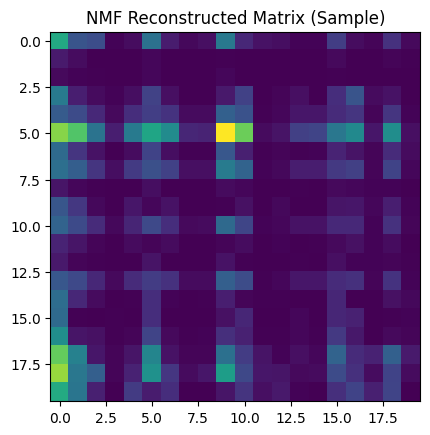

In [30]:
plt.imshow(predicted_ratings.values[:20, :20])
plt.title("NMF Reconstructed Matrix (Sample)")
plt.show()